<a href="https://colab.research.google.com/github/BhavikBuchke/Cisco-Data-science-program/blob/main/Data%20modeling/Lion%20Nose%20Color%20Project/lion%20nose%20color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lion Nose Color

Can you estimate a lion's age from a photograph of its nose?

Lions are born with pink noses that gradually darken with age, developing black freckles until they eventually turn completely black.

The dataset `lion-nose-color.csv` contains data on 91 lions from the Serengeti, each monitored by researchers since birth. Because their exact ages are known, researchers can analyze photographs to determine the percentage of black on their noses and assess how well nose coloration predicts age.

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'lion-nose-color.csv' and 'linear_model.py'.

from google.colab import files
uploaded = files.upload()

Saving linear_model.py to linear_model.py
Saving lion-nose-color.csv to lion-nose-color.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('lion-nose-color.csv')
df.head()

,age,proportion_black
0,1.10,21.1
1,4.19,34.9
2,1.91,26.8
3,8.16,84.8
4,7.32,47.9


# Project Ideas

- Create a linear regression model to predict `age` from `proportion_black`

- Use the model to estimate a lion's age when its nose is 50% black.

#### Considerations
- Can you determine a lion's age when its nose is 100% black? Why or why not?

In [ ]:
lion_age_100_black = linear.predict(100.0)
print(f"Lion's estimated age when its nose is 100% black is {lion_age_100_black:.2f} years.")

In [ ]:
df.describe()

,age,proportion_black
count,91.000000,91.000000
mean,4.720220,41.079121
std,2.373761,25.570054
min,1.050000,5.000000
25%,2.675000,20.350000
50%,4.220000,36.400000
75%,6.740000,59.600000
max,9.790000,100.000000


In [ ]:
def clr_visual():
  ax= plt.gca()
  ax.spines[['top','bottom','right','left']].set_visible(False)
  ax.tick_params(axis= 'both', length= 0)
  ax.grid()
  plt.xlabel('Proportion Black')
  plt.ylabel('Age')
  return ax

LinearModel():
Slope: 0.0786892093319344
Intercept: 1.4877362381908004
R-squared: 0.7184884343030967


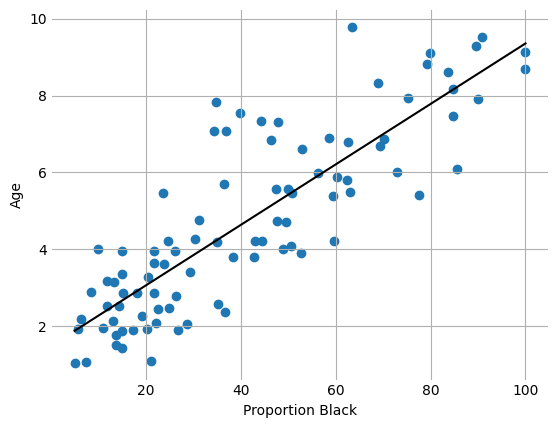

In [ ]:
# Linear model API
x=df['proportion_black']
y=df['age']
x_min = x.min()
x_max = x.max()
linear = LinearModel()
linear.fit(x, y)
plt.scatter(x,y)
linear.plot_model(x_min, x_max, color="black")
clr_visual()
linear.print_model_info()


In [ ]:
# Lion's age when its nose is 50% black.
lion_age = linear.predict(50.0)
print(f"Lion's age when its nose is 50% black is {lion_age:.2f} years.")

Lion's age when its nose is 50% black is 5.42 years.


We can use our linear regression model to estimate a lion’s age when its nose is 100% black because our dataset actually includes values of proportion_black up to 100%. Since the model was trained on data that covers this full range, predicting at 100% black is valid and supported by the training data.

That said, it’s still worth being cautious. Even when a value is inside the dataset range, predictions near the extreme end (like the maximum) can sometimes be a bit less stable than predictions made in the middle of the range. But overall, because 100% black is included in the observed data, this estimate should be fairly reliable within the context of our model.

Also, df.describe() confirms that the maximum proportion_black value is 100.0, so we’re not going beyond what the model has already seen.